In [3]:
import os
import kagglehub
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [5]:
dataset_path = kagglehub.dataset_download("emmarex/plantdisease")

data_dir = None
for folder in os.listdir(dataset_path):
    full_path = os.path.join(dataset_path, folder)
    if os.path.isdir(full_path):
        data_dir = full_path
        break

print("Data folder:", data_dir)

Using Colab cache for faster access to the 'plantdisease' dataset.
Data folder: /kaggle/input/plantdisease/PlantVillage


In [6]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [7]:
full_dataset = datasets.ImageFolder(root=data_dir)

class_names = full_dataset.classes
num_classes = len(class_names)

print("Classes:", num_classes)

Classes: 15


In [8]:
import numpy as np

indices = np.arange(len(full_dataset))
labels = np.array(full_dataset.targets)

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.3,
    stratify=labels,
    random_state=42
)

val_idx, test_idx = train_test_split(
    test_idx,
    test_size=0.5,
    stratify=labels[test_idx],
    random_state=42
)

In [9]:
from torch.utils.data import Subset

train_dataset = Subset(datasets.ImageFolder(data_dir, transform=train_transform), train_idx)
val_dataset = Subset(datasets.ImageFolder(data_dir, transform=test_transform), val_idx)
test_dataset = Subset(datasets.ImageFolder(data_dir, transform=test_transform), test_idx)

In [10]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [11]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = True

model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 170MB/s]


In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [13]:
epochs = 2

for epoch in range(epochs):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

    acc = 100 * correct / total

    print(f"Epoch {epoch+1}")
    print(f"Loss: {total_loss:.4f}")
    print(f"Train Acc: {acc:.2f}%")

Epoch 1
Loss: 125.8034
Train Acc: 92.58%
Epoch 2
Loss: 28.8903
Train Acc: 98.19%


In [14]:
model.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

In [15]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.99      1.00      1.00       149
                     Pepper__bell___healthy       1.00      1.00      1.00       221
                      Potato___Early_blight       1.00      0.97      0.99       150
                       Potato___Late_blight       0.94      0.99      0.97       150
                           Potato___healthy       1.00      0.96      0.98        23
                      Tomato_Bacterial_spot       0.99      0.99      0.99       319
                        Tomato_Early_blight       0.97      0.95      0.96       150
                         Tomato_Late_blight       0.98      0.98      0.98       287
                           Tomato_Leaf_Mold       0.99      1.00      1.00       143
                  Tomato_Septoria_leaf_spot       0.99      1.00      0.99       266
Tomato_Spider_mites_Two_spotted_spider_mite       1.00      0.98

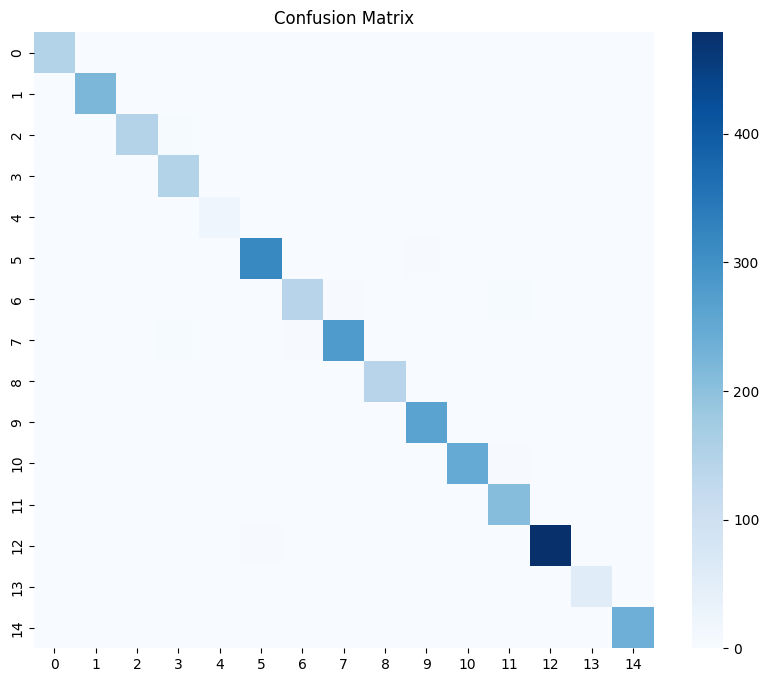

In [16]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()